# 04 - Statistical Analysis


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/cleaned_data.csv')

In [2]:
%pip install seaborn scipy scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/moulisrivastava/Desktop/E_G1_DVACapstone2/.venv/bin/python3.14 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### 1. Correlation Checks (Spearman)
Check how discount, rating, reviews, and price move with purchases.


                      discount_pct  rating  number_of_reviews  current_price  \
discount_pct                 1.000  -0.032              0.098         -0.229   
rating                      -0.032   1.000              0.145         -0.307   
number_of_reviews            0.098   0.145              1.000         -0.440   
current_price               -0.229  -0.307             -0.440          1.000   
bought_in_last_month         0.172   0.267              0.633         -0.621   

                      bought_in_last_month  
discount_pct                         0.172  
rating                               0.267  
number_of_reviews                    0.633  
current_price                       -0.621  
bought_in_last_month                 1.000  


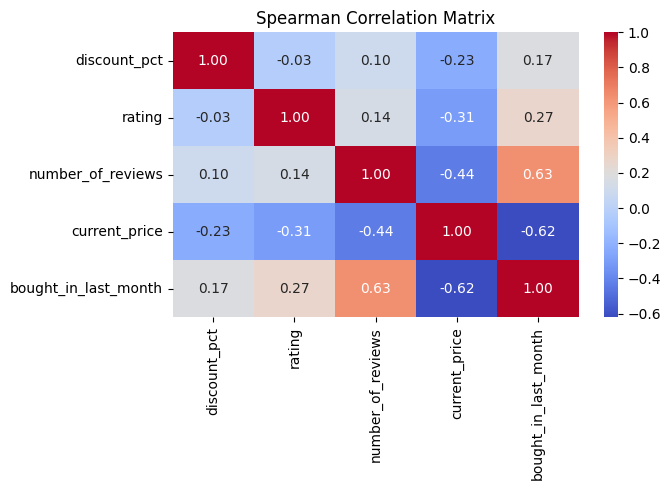

In [3]:
import numpy as np
import seaborn as sns
from scipy.stats import mannwhitneyu
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('../data/processed/cleaned_data.csv')
df['discount_pct'] = ((df['listed_price'] - df['current_price']) / df['listed_price']) * 100
df['discount_pct'] = df['discount_pct'].replace([np.inf, -np.inf], np.nan).fillna(0).clip(lower=0)

num_cols = ['discount_pct', 'rating', 'number_of_reviews', 'current_price', 'bought_in_last_month']
corr = df[num_cols].corr(method='spearman')
print(corr.round(3))

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Spearman Correlation Matrix')
plt.tight_layout()
plt.show()


### 2. Hypothesis Test: Coupon vs No Coupon
Use Mann-Whitney U to test whether coupon products have different purchase levels.


In [4]:
coupon = df[df['has_coupon'] == 1]['bought_in_last_month'].dropna()
no_coupon = df[df['has_coupon'] == 0]['bought_in_last_month'].dropna()

stat, p_value = mannwhitneyu(coupon, no_coupon, alternative='two-sided')

print('Median purchases (coupon):', coupon.median())
print('Median purchases (no coupon):', no_coupon.median())
print('Mann-Whitney U p-value:', p_value)



Median purchases (coupon): 50.0
Median purchases (no coupon): 100.0
Mann-Whitney U p-value: 3.02973637874917e-10


### 3. Driver Ranking 
Rank important purchase drivers using Spearman correlation (easy to interpret and model-free).


          feature  spearman_rho  abs_strength
2     log_reviews      0.632837      0.632837
3   current_price     -0.620954      0.620954
1          rating      0.267291      0.267291
0    discount_pct      0.172172      0.172172
5  is_best_seller      0.111861      0.111861
4      has_coupon     -0.035809      0.035809


/var/folders/w2/24y_cc01253dn2pmqgml430w0000gp/T/ipykernel_42214/2853326756.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=driver_table, x='feature', y='spearman_rho', palette='viridis')


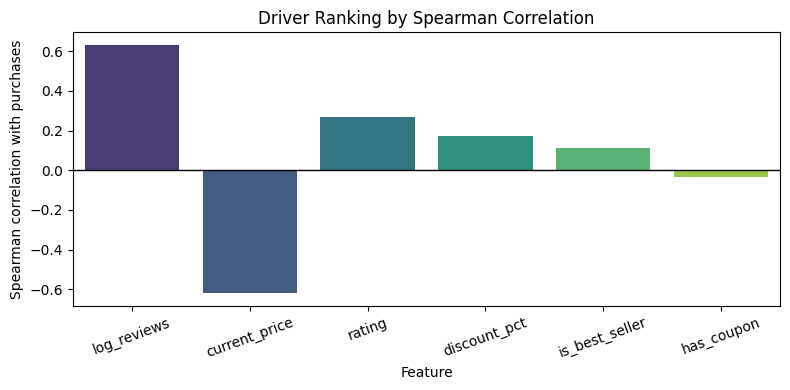

In [5]:
rank_df = df.copy()
rank_df['log_reviews'] = np.log1p(rank_df['number_of_reviews'])

features = ['discount_pct', 'rating', 'log_reviews', 'current_price', 'has_coupon', 'is_best_seller']
target = 'bought_in_last_month'

driver_rows = []
for f in features:
    rho = rank_df[[f, target]].corr(method='spearman').iloc[0, 1]
    driver_rows.append({'feature': f, 'spearman_rho': rho, 'abs_strength': abs(rho)})

driver_table = pd.DataFrame(driver_rows).sort_values('abs_strength', ascending=False)
print(driver_table)

# Visual ranking for dashboard-ready interpretation
plt.figure(figsize=(8, 4))
sns.barplot(data=driver_table, x='feature', y='spearman_rho', palette='viridis')
plt.axhline(0, color='black', linewidth=1)
plt.title('Driver Ranking by Spearman Correlation')
plt.xlabel('Feature')
plt.ylabel('Spearman correlation with purchases')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 4. Category Value Score (CVI-style)
Create a simple weighted score combining discount, rating, and review engagement.


                       avg_value_score  avg_discount  avg_rating  \
product_category                                                   
Smartphones                   0.394710     22.301378    4.439432   
Office Supplies               0.379579     13.835680    4.639474   
Cables & Chargers             0.377281     17.679933    4.473621   
Wearables                     0.372479     16.934366    4.456098   
Batteries                     0.358118      8.190360    4.674452   
Smart Home & Security         0.345654     11.535307    4.401899   
Laptops & Computers           0.342713     12.355149    4.333431   
Storage & Memory              0.341478      8.544030    4.478495   
Computer Accessories          0.341142      5.886034    4.607963   
Microphones                   0.340828      8.723949    4.477705   
Networking                    0.337609     11.284100    4.322883   
Printers & Ink                0.331125      6.884676    4.454633   
Audio & Speakers              0.328371      7.38

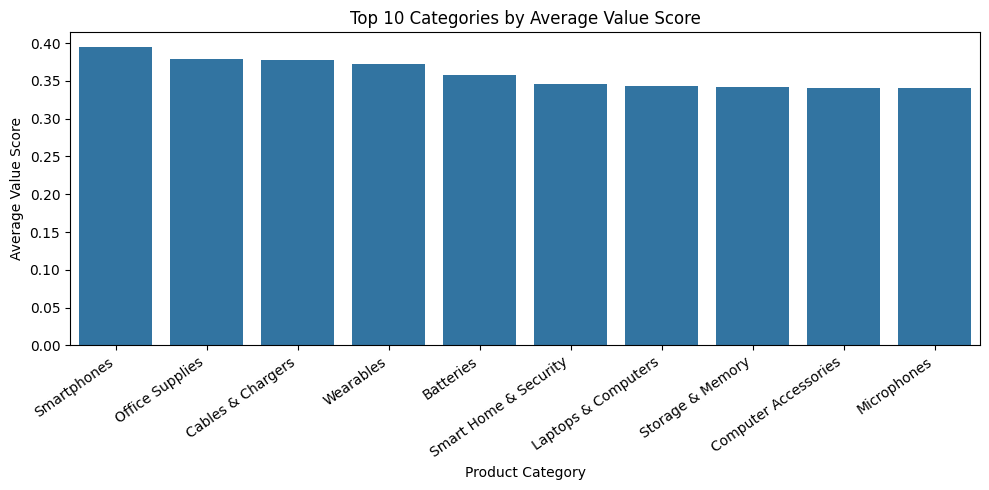

In [6]:
score_df = df.copy()
scaler = MinMaxScaler()
score_df[['discount_n', 'rating_n', 'reviews_n']] = scaler.fit_transform(
    score_df[['discount_pct', 'rating', 'number_of_reviews']]
)

score_df['value_score'] = (
    0.35 * score_df['discount_n'] +
    0.35 * score_df['rating_n'] +
    0.30 * score_df['reviews_n']
)

cat_score = score_df.groupby('product_category').agg(
    avg_value_score=('value_score', 'mean'),
    avg_discount=('discount_pct', 'mean'),
    avg_rating=('rating', 'mean'),
    avg_reviews=('number_of_reviews', 'mean'),
    n_products=('title', 'count')
).sort_values('avg_value_score', ascending=False)

print(cat_score.head(15))

# Visual compare: top categories by value score
top_cat_score = cat_score.head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_cat_score, x='product_category', y='avg_value_score')
plt.title('Top 10 Categories by Average Value Score')
plt.xlabel('Product Category')
plt.ylabel('Average Value Score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()


### 5. Price-Tier Performance
Compare category performance across low, mid, and premium price tiers.


In [7]:
tier_df = df.copy()
tier_df['price_tier'] = pd.qcut(
    tier_df['current_price'].rank(method='first'),
    q=3,
    labels=['Low', 'Mid', 'Premium']
)

tier_perf = tier_df.groupby(['product_category', 'price_tier'], observed=True).agg(
    avg_price=('current_price', 'mean'),
    avg_discount=('discount_pct', 'mean'),
    avg_rating=('rating', 'mean'),
    avg_reviews=('number_of_reviews', 'mean'),
    avg_purchases=('bought_in_last_month', 'mean'),
    n_products=('title', 'count')
).reset_index()

print(tier_perf.head(30))


         product_category price_tier    avg_price  avg_discount  avg_rating  \
0        Audio & Speakers        Low    21.994915      5.424675    4.528249   
1        Audio & Speakers        Mid    62.503777     13.365623    4.307880   
2        Audio & Speakers    Premium   341.099384      4.421517    4.411920   
3               Batteries        Low    18.688502      8.354971    4.759628   
4               Batteries        Mid    62.620602      9.689350    4.128916   
5               Batteries    Premium   267.456796      2.338468    3.775728   
6       Cables & Chargers        Low    22.602380     21.021810    4.528594   
7       Cables & Chargers        Mid    85.441306     16.890764    4.439172   
8       Cables & Chargers    Premium   205.949528      2.605957    4.278740   
9   Cameras & Photography        Low    27.771925     20.601445    4.473292   
10  Cameras & Photography        Mid    80.673306      1.796129    4.422561   
11  Cameras & Photography    Premium  1078.864603   

### 6. Best-Seller vs Non-Best-Seller Test
Check whether best-seller products differ in purchases, ratings, and discount levels.


In [8]:
best = df[df['is_best_seller'] == 1]
non_best = df[df['is_best_seller'] == 0]

u1, p1 = mannwhitneyu(best['bought_in_last_month'].dropna(), non_best['bought_in_last_month'].dropna(), alternative='two-sided')
u2, p2 = mannwhitneyu(best['rating'].dropna(), non_best['rating'].dropna(), alternative='two-sided')
u3, p3 = mannwhitneyu(best['discount_pct'].dropna(), non_best['discount_pct'].dropna(), alternative='two-sided')

print('Median purchases (best vs non-best):', best['bought_in_last_month'].median(), non_best['bought_in_last_month'].median(), '| p =', p1)
print('Median rating (best vs non-best):', best['rating'].median(), non_best['rating'].median(), '| p =', p2)
print('Median discount% (best vs non-best):', best['discount_pct'].median(), non_best['discount_pct'].median(), '| p =', p3)


Median purchases (best vs non-best): 6000.0 100.0 | p = 3.796071692533924e-86
Median rating (best vs non-best): 4.6 4.5 | p = 7.665775643994094e-05
Median discount% (best vs non-best): 18.33791781278653 0.0 | p = 1.0299664266171073e-28
